In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [48]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

print("Fund Master Shape:", fund_master.shape)
print("NAV History Shape:", nav_history.shape)

Fund Master Shape: (40, 15)
NAV History Shape: (46000, 3)


In [49]:
print("\nFund Master Columns:")
print(fund_master.columns.tolist())

print("\nNAV History Columns:")
print(nav_history.columns.tolist())


Fund Master Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History Columns:
['amfi_code', 'date', 'nav']


In [50]:
print("Unique Funds:",
      nav_history["amfi_code"].nunique())

display(nav_history.head())

Unique Funds: 40


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [51]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [52]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [53]:
print(
    "Missing Daily Returns:",
    nav_history["daily_return"].isna().sum()
)

Missing Daily Returns: 40


In [54]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

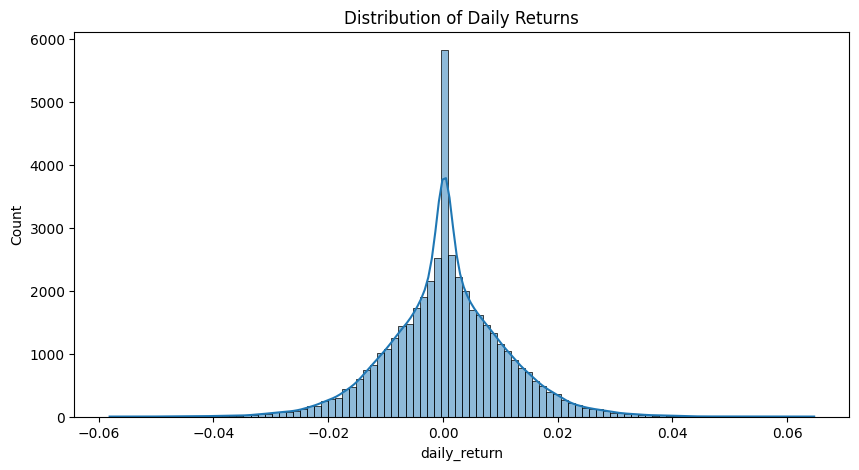

In [55]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav_history["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

In [56]:
nav_history["daily_return"].agg(
    ["min", "max", "mean", "std"]
)

min    -0.058102
max     0.064713
mean    0.000631
std     0.010290
Name: daily_return, dtype: float64

In [57]:
print("Earliest Date:", nav_history["date"].min())
print("Latest Date:", nav_history["date"].max())

Earliest Date: 2022-01-03 00:00:00
Latest Date: 2026-05-29 00:00:00


In [58]:
nav_history.groupby("amfi_code")["date"].agg(
    ["min", "max"]
).head()

,min,max
amfi_code,,
100016,2022-01-03,2026-05-29
100025,2022-01-03,2026-05-29
100033,2022-01-03,2026-05-29
101206,2022-01-03,2026-05-29
101207,2022-01-03,2026-05-29


In [59]:
latest_date = nav_history["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [60]:
def calculate_cagr(nav_start, nav_end, years):
    
    if nav_start <= 0 or nav_end <= 0:
        return np.nan

    return (nav_end / nav_start) ** (1 / years) - 1

In [61]:
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]

    row = {"amfi_code": fund}

    for years in [1, 3, 5]:

        required_start = latest_date - pd.DateOffset(years=years)

        earliest_available = fund_data["date"].min()

        if earliest_available > required_start:

            row[f"CAGR_{years}Y"] = np.nan

        else:

            start_nav = fund_data[
                fund_data["date"] >= required_start
            ].iloc[0]["nav"]

            row[f"CAGR_{years}Y"] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.iloc[:,1:] = cagr_df.iloc[:,1:] * 100

In [62]:
cagr_df.isna().sum()

amfi_code     0
CAGR_1Y       0
CAGR_3Y       0
CAGR_5Y      40
dtype: int64

In [63]:
cagr_df.describe()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000,0.0
mean,120247.000000,19.428520,16.414715,NaN
std,14534.998667,22.912276,12.206752,NaN
min,100016.000000,-42.797615,-11.705807,NaN
25%,118632.750000,7.377949,6.600925,NaN
50%,119551.500000,17.474125,18.233102,NaN
75%,120842.250000,27.161651,26.902600,NaN
max,149324.000000,82.776059,35.111802,NaN


In [64]:
cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,22.261065,35.111802,NaN
34,148567,20.360678,34.000916,NaN
24,120504,13.064279,32.487429,NaN
2,100033,53.232396,32.442459,NaN
25,120505,29.604659,31.777537,NaN
19,119551,60.437341,30.456524,NaN
30,120843,26.657082,29.582770,NaN
36,148569,39.751761,29.178902,NaN
3,101206,47.924120,28.967695,NaN
39,149324,65.138719,27.000427,NaN


In [65]:
rf_annual = 0.065

rf_daily = rf_annual / 252

print(rf_daily)

0.00025793650793650796


In [66]:
sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = (
        (mean_return - rf_daily)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "mean_daily_return": mean_return,
        "volatility": std_return,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [67]:
sharpe_df.head()

,amfi_code,mean_daily_return,volatility,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [68]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,mean_daily_return,volatility,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


In [69]:
sharpe_df["sharpe_ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64

In [70]:
sortino_results = []

for fund in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    mean_return = returns.mean()

    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std()

    sortino = (
        (mean_return - rf_daily)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": fund,
        "sortino_ratio": sortino,
        "downside_std": downside_std
    })

sortino_df = pd.DataFrame(sortino_results)

In [71]:
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio,downside_std
34,148567,2.385644,0.005428
30,120843,2.364320,0.005531
36,148569,2.146914,0.006404
19,119551,2.140267,0.004887
25,120505,2.029353,0.007067
38,149323,1.875101,0.006750
9,118632,1.850133,0.005211
2,100033,1.829134,0.007133
24,120504,1.805294,0.005145
3,101206,1.799563,0.005238


In [72]:
sortino_df["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [73]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        if "nifty" in file.lower() or "benchmark" in file.lower():
            print(os.path.join(root, file))

../data\processed\10_benchmark_indices.csv
../data\raw\10_benchmark_indices.csv


In [74]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print("Shape:", benchmark.shape)

print("\nColumns:")
print(benchmark.columns.tolist())

display(benchmark.head())

Shape: (8050, 3)

Columns:
['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [75]:
for col in benchmark.columns:
    print(col)

date
index_name
close_value


In [76]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

print(
    benchmark["date"].min()
)

print(
    benchmark["date"].max()
)

2022-01-03 00:00:00
2026-05-29 00:00:00


In [77]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [78]:
from scipy.stats import linregress

print("linregress imported successfully")

linregress imported successfully


In [79]:
print(type(linregress))

<class 'function'>


In [80]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "alpha": intercept * 252,
        "beta": slope,
        "r_squared": r_value**2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [81]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

print(nifty100.shape)

nifty100.head()

(1150, 4)


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [82]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


In [83]:
alpha_beta_df["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [84]:
merged_test = pd.merge(
    nav_history[
        nav_history["amfi_code"] == nav_history["amfi_code"].iloc[0]
    ][["date", "daily_return"]],
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print(merged_test.shape)

display(merged_test.head())

display(merged_test.tail())

(1150, 3)


,date,daily_return,benchmark_return
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150


,date,daily_return,benchmark_return
1145,2026-05-25,-0.004227,0.002732
1146,2026-05-26,-0.005819,-0.000912
1147,2026-05-27,-0.009367,0.013582
1148,2026-05-28,0.000152,0.009684
1149,2026-05-29,-0.012410,0.000931


In [85]:
print(
    nav_history["date"].nunique()
)

print(
    nifty100["date"].nunique()
)

1150
1150


In [86]:
drawdown_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    drawdown_results.append({
        "amfi_code": fund,
        "max_drawdown": max_dd,
        "worst_date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(
    drawdown_results
)

In [87]:
drawdown_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [88]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown,worst_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


In [89]:
drawdown_df["max_drawdown"].describe()

count    40.000000
mean     -0.178729
std       0.112686
min      -0.525742
25%      -0.215927
50%      -0.163070
75%      -0.117653
max      -0.000977
Name: max_drawdown, dtype: float64

In [90]:
scorecard = cagr_df[
    ["amfi_code", "CAGR_3Y"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,CAGR_3Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,1.292649,-0.201517,0.037476,-0.247344,1.55
1,100025,3.916390,-0.567095,0.042818,-0.043083,0.56
2,100033,32.442459,1.093699,0.271954,-0.162172,1.38
3,101206,28.967695,1.027213,0.213998,-0.112916,1.60
4,101207,-4.152381,0.162661,0.108971,-0.354469,1.53


In [91]:
scorecard["return_rank"] = (
    scorecard["CAGR_3Y"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)


In [92]:
n = len(scorecard)

for col in [
    "return_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "drawdown_rank"
]:
    scorecard[col] = (
        (n - scorecard[col])
        / (n - 1)
    ) * 100

scorecard["fund_score"] = (

      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]

)

In [93]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_3Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
34,148567,34.000916,1.448291,0.269838,-0.112657,1.46,97.435897,100.000000,84.615385,43.589744,82.051282,85.897436
25,120505,31.777537,1.180101,0.292636,-0.181885,1.36,89.743590,89.743590,94.871795,64.102564,38.461538,81.794872
30,120843,29.582770,1.306744,0.273305,-0.129740,1.45,84.615385,97.435897,89.743590,46.153846,69.230769,81.538462
2,100033,32.442459,1.093699,0.271954,-0.162172,1.38,92.307692,84.615385,87.179487,58.974359,51.282051,80.256410
24,120504,32.487429,1.026524,0.211948,-0.125883,0.80,94.871795,76.923077,69.230769,71.794872,71.794872,79.487179
16,119094,35.111802,0.998231,0.260767,-0.209609,1.38,100.000000,74.358974,79.487179,58.974359,30.769231,76.410256
19,119551,30.456524,1.208267,0.232010,-0.150124,1.54,87.179487,92.307692,76.923077,24.358974,58.974359,74.166667
36,148569,29.178902,1.234930,0.282704,-0.163967,1.60,82.051282,94.871795,92.307692,8.974359,48.717949,73.012821
3,101206,28.967695,1.027213,0.213998,-0.112916,1.60,79.487179,79.487179,71.794872,8.974359,79.487179,67.371795
21,119598,26.669922,0.945308,0.303370,-0.287060,1.43,71.794872,66.666667,100.000000,48.717949,10.256410,66.538462


In [94]:
scorecard["fund_score"].describe()

count    40.000000
mean     50.000000
std      21.404119
min      12.115385
25%      32.724359
50%      51.057692
75%      66.057692
max      85.897436
Name: fund_score, dtype: float64

In [95]:
import os

print(os.getcwd())

C:\Users\91630\mutual_fund_analytics\notebooks


In [96]:
import os

os.makedirs("../outputs", exist_ok=True)

scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [97]:
import os

os.listdir("..")

['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'bluestock_mf.db',
 'dashboard',
 'data',
 'docs',
 'EDA_Analysis.ipynb',
 'notebooks',
 'outputs',
 'reports',
 'requirements.txt',
 'scripts',
 'sql',
 'venv']

In [98]:
import os

print(
    os.path.exists("../outputs")
)

True


In [99]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [100]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [101]:
top5_funds = (
    scorecard
    .head(5)["amfi_code"]
    .tolist()
)

print(top5_funds)

[148567, 120505, 120843, 100033, 120504]


In [102]:
fund_master[
    fund_master["amfi_code"].isin(top5_funds)
][["amfi_code","scheme_name"]]

,amfi_code,scheme_name
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
11,120504,ICICI Pru Bluechip Fund - Direct - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
22,120843,Kotak Flexicap Fund - Regular - Growth
34,148567,Mirae Asset Large Cap Fund - Regular - Growth


In [103]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

latest_date = nav_history["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

print("Start:", start_date)
print("End:", latest_date)

Start: 2023-05-29 00:00:00
End: 2026-05-29 00:00:00


In [104]:
nifty50_3y = nifty50[
    nifty50["date"] >= start_date
].copy()

nifty100_3y = nifty100[
    nifty100["date"] >= start_date
].copy()

nifty50_3y["normalized"] = (
    nifty50_3y["close_value"]
    / nifty50_3y["close_value"].iloc[0]
) * 100

nifty100_3y["normalized"] = (
    nifty100_3y["close_value"]
    / nifty100_3y["close_value"].iloc[0]
) * 100

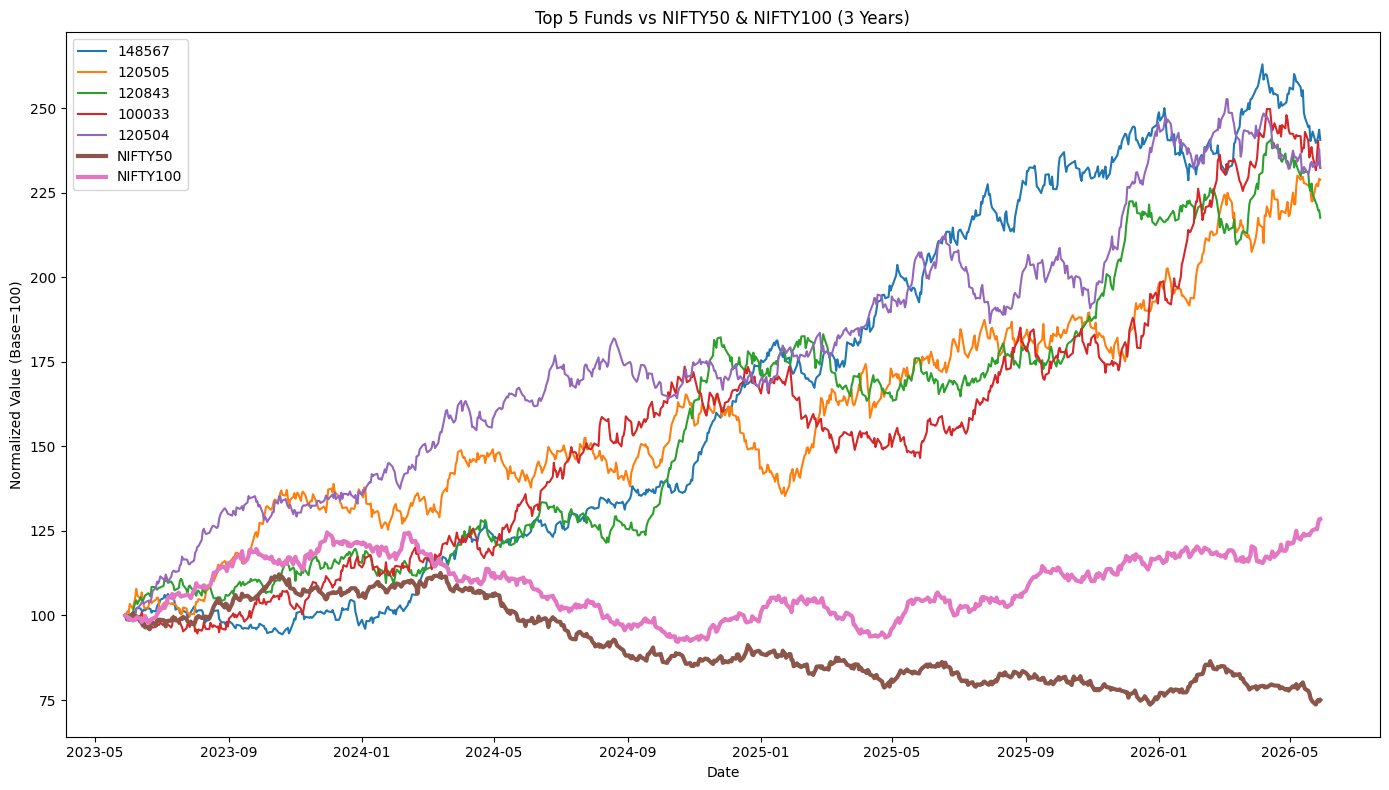

In [105]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = nav_history[
        (nav_history["amfi_code"] == fund)
        &
        (nav_history["date"] >= start_date)
    ].copy()

    fund_data["normalized"] = (
        fund_data["nav"]
        / fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["normalized"],
        label=str(fund)
    )

plt.plot(
    nifty50_3y["date"],
    nifty50_3y["normalized"],
    label="NIFTY50",
    linewidth=3
)

plt.plot(
    nifty100_3y["date"],
    nifty100_3y["normalized"],
    label="NIFTY100",
    linewidth=3
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Value (Base=100)")
plt.legend()

plt.tight_layout()

plt.show()

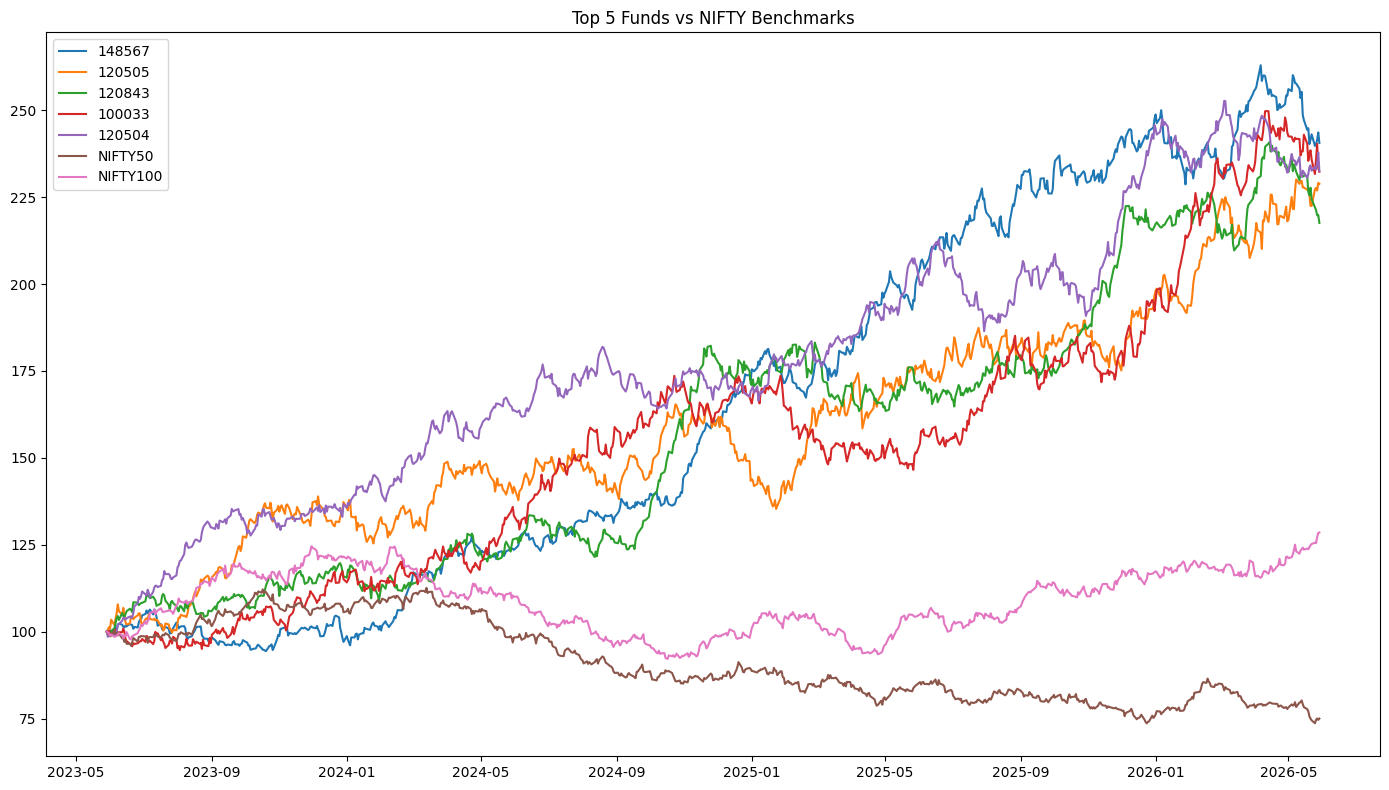

In [106]:
plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = nav_history[
        (nav_history["amfi_code"] == fund)
        &
        (nav_history["date"] >= start_date)
    ].copy()

    fund_data["normalized"] = (
        fund_data["nav"]
        / fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["normalized"],
        label=str(fund)
    )

plt.plot(
    nifty50_3y["date"],
    nifty50_3y["normalized"],
    label="NIFTY50"
)

plt.plot(
    nifty100_3y["date"],
    nifty100_3y["normalized"],
    label="NIFTY100"
)

plt.legend()

plt.title(
    "Top 5 Funds vs NIFTY Benchmarks"
)

plt.tight_layout()

plt.savefig(
    "../outputs/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value']


In [109]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

print(nifty100.columns.tolist())

nifty100.head()

['date', 'index_name', 'close_value', 'benchmark_return']


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [110]:
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [111]:
tracking_error_results = []

for fund in top5_funds:

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] -
         merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": fund,
        "tracking_error": tracking_error
    })

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

tracking_error_df

,amfi_code,tracking_error
0,148567,0.189664
1,120505,0.231968
2,120843,0.206425
3,100033,0.228699
4,120504,0.191587


In [112]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

In [113]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [115]:
tracking_error_df.to_csv(
    "../outputs/tracking_error.csv",
    index=False
)

drawdown_df.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

print("Files saved successfully")

Files saved successfully


In [116]:
import os

print(os.listdir("../outputs"))

['.ipynb_checkpoints', 'alpha_beta.csv', 'benchmark_comparison.png', 'fund_scorecard.csv', 'max_drawdown.csv', 'tracking_error.csv']
